# Historical FIRMS and ICS-209 Check

purpose of this notebook is to get a bit of background on how the clustering will work using the historical FIRMS data and ICS-209 data. Will pull a peak fire season month (Aug 2023) to look at actual data volume, confidence distributions, and satellite pass gaps (compared to ICS-209). Then map this back to a known historical incident reported in ICS-209, which would validate a labeling strategy.

ICS-209-PLUS download: https://www.fs.usda.gov/rds/archive/Catalog/RDS-2013-0017

In [20]:
import os
from dotenv import load_dotenv
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO, BytesIO
from shapely.geometry import Point
from datetime import date, timedelta
from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/eda_historical_ics209", exist_ok=True)
load_dotenv()

True

In [2]:
MAP_KEY = os.getenv("MAP_KEY", "<get_your_own_key_buddy>")
CA_BBOX = "-124.41060660766607,32.5342307609976,-114.13445790587905,42.00965914828148"

# Aug 2023 is a peak CA fire season
HISTORICAL_START = "2023-08-01"
HISTORICAL_DAYS = 31

# using SNPP since it's the standard processing product (archive quality, preferred for training data)
PRODUCT = "VIIRS_SNPP_SP"

## historical FIRMS Sample (Aug 2023)

In [4]:
# FIRMS area endpoint caps at 5 days per request, chunk across the month
def fetch_firms_chunk(product, bbox, start_date, days, map_key):
    url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{product}/{bbox}/{days}/{start_date}"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return pd.read_csv(StringIO(resp.content.decode("utf-8")))


chunks = []
start = date.fromisoformat(HISTORICAL_START)
remaining = HISTORICAL_DAYS
while remaining > 0:
    chunk_days = min(5, remaining)
    print(f"Fetching {chunk_days} days from {start}...")
    df = fetch_firms_chunk(PRODUCT, CA_BBOX, start.isoformat(), chunk_days, MAP_KEY)
    chunks.append(df)
    start += timedelta(days=chunk_days)
    remaining -= chunk_days

hist_df = pd.concat(chunks, ignore_index=True)
hist_df["acq_datetime"] = pd.to_datetime(
    hist_df["acq_date"].astype(str)
    + " "
    + hist_df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    utc=True,
)
print(f"\nTotal hotspots (Aug 2023): {len(hist_df)}")
hist_df.head()

Fetching 5 days from 2023-08-01...
Fetching 5 days from 2023-08-06...
Fetching 5 days from 2023-08-11...
Fetching 5 days from 2023-08-16...
Fetching 5 days from 2023-08-21...
Fetching 5 days from 2023-08-26...
Fetching 1 days from 2023-08-31...

Total hotspots (Aug 2023): 10288


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,acq_datetime
0,36.35595,-114.91316,313.69,0.35,0.57,2023-08-01,848,N,VIIRS,n,2,287.87,1.60,N,2,2023-08-01 08:48:00+00:00
1,36.35752,-114.91074,304.40,0.35,0.57,2023-08-01,848,N,VIIRS,n,2,287.10,2.06,N,2,2023-08-01 08:48:00+00:00
2,32.69083,-115.32108,306.35,0.34,0.56,2023-08-01,849,N,VIIRS,n,2,290.46,2.29,N,0,2023-08-01 08:49:00+00:00
3,38.01626,-122.11298,304.65,0.40,0.44,2023-08-01,1028,N,VIIRS,n,2,287.81,1.42,N,2,2023-08-01 10:28:00+00:00
4,38.36104,-121.21399,296.56,0.44,0.46,2023-08-01,1028,N,VIIRS,n,2,279.28,1.25,N,0,2023-08-01 10:28:00+00:00


In [5]:
hist_gdf = gpd.GeoDataFrame(
    hist_df,
    geometry=gpd.points_from_xy(hist_df["longitude"], hist_df["latitude"]),
    crs="EPSG:4326",
)

### data volume and distribution

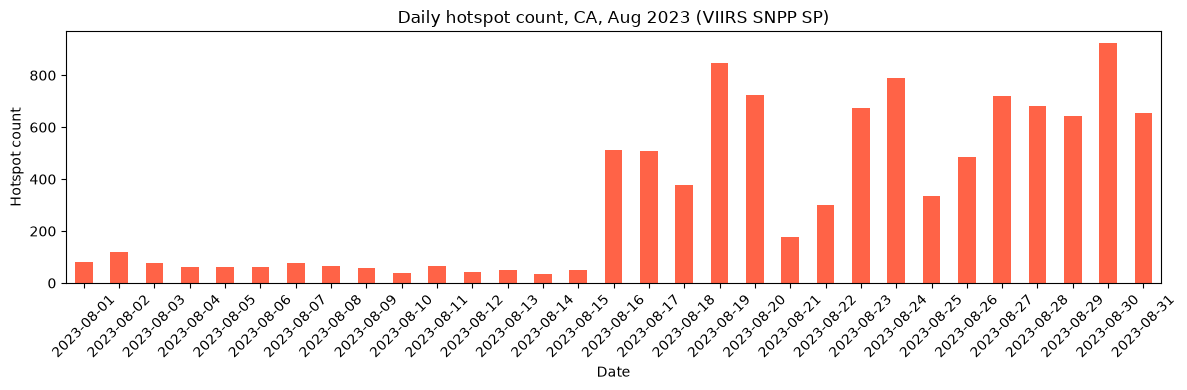

Min: 35, Max: 923, Mean: 332 hotspots/day
Daily hotspot count stats:


count     31.000000
mean     331.870968
std      304.331261
min       35.000000
25%       62.000000
50%      177.000000
75%      649.000000
max      923.000000
dtype: float64

In [29]:
daily = hist_df.groupby("acq_date").size()

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, kind="bar", color="tomato", edgecolor="none")
ax.set_title("Daily hotspot count, CA, Aug 2023 (VIIRS SNPP SP)")
ax.set_xlabel("Date")
ax.set_ylabel("Hotspot count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/daily_hotspot_count.png", dpi=150, bbox_inches="tight"
)
plt.show()

print(f"Min: {daily.min()}, Max: {daily.max()}, Mean: {daily.mean():.0f} hotspots/day")
print("Daily hotspot count stats:")
daily.describe()

### confidence distrobution

In [7]:
conf_counts = hist_df["confidence"].value_counts()
print("Confidence distribution:")
print(conf_counts)
print(f"\nLow-confidence fraction: {conf_counts.get('l', 0) / len(hist_df):.1%}")

frp_by_conf = hist_df.groupby("confidence")["frp"].describe()
print("\nFRP by confidence:")
print(frp_by_conf)

Confidence distribution:
confidence
n    9443
h     478
l     367
Name: count, dtype: int64

Low-confidence fraction: 3.6%

FRP by confidence:
             count       mean        std  min     25%     50%    75%     max
confidence                                                                  
h            478.0  47.967908  66.465704  0.0  11.725  20.965  57.84  594.39
l            367.0  50.888174  80.567146  0.0   4.610  12.840  66.08  594.39
n           9443.0   7.876478  19.151267  0.0   1.280   2.890   6.92  347.88


Seeing that low confidence (l) have higher mean FRP than nominal (n). I'm assuming this is because VIIRS confidence is based on certainty (ie. is this a fire?), not necessarily accuracy. The low confidence values being high could be from edge pixels of intense fires, so edge pixels of intense fires may have low confidence it is a fire, but because it is overall an intense fire, the FRP values are high. The count counts between low and nominal are also drastically different, so it could be a few outliers in the low confidence skewing the average, which yeah looking at the std and actual distribution that seems to be case (low has a much larger max than the 25-50-75), same case for high confidence. These outliers could be a result of the edge pixel idea.

### satellite pass schedule

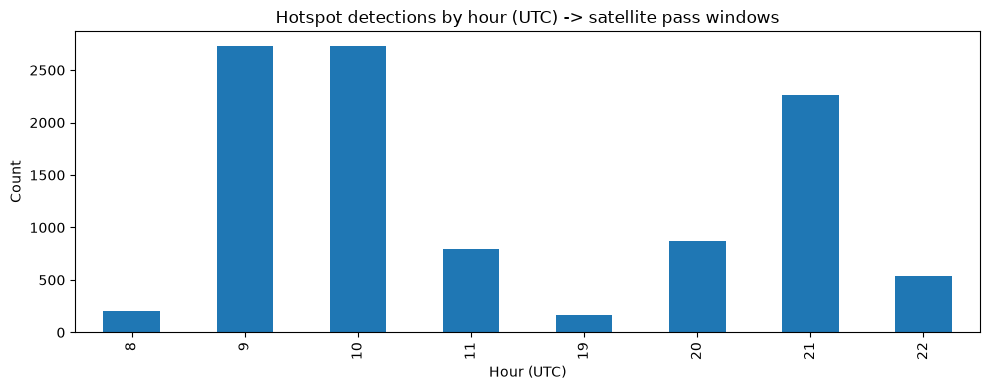

Acquisition hour stats:


count    10288.000000
mean        13.804432
std          5.457601
min          8.000000
25%          9.000000
50%         10.000000
75%         21.000000
max         22.000000
Name: acq_hour, dtype: float64

In [15]:
# acq_time is HHMM UTC, convert to hour
hist_df["acq_hour"] = hist_df["acq_time"] // 100

fig, ax = plt.subplots(figsize=(10, 4))
hist_df["acq_hour"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax,
)
ax.set_title("Hotspot detections by hour (UTC) -> satellite pass windows")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/pass_windows.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("Acquisition hour stats:")
hist_df["acq_hour"].describe()

multi-hour gaps between passes doesn't necessarily mean the fire was extinguished, could be a detection gap

In [ ]:
# look at day/night pass detections, and locations seen in both passes on the same day
# Fires detected in both day/night passes are persistent/high-intensity and could give strong clustering signal

hist_df["pass_window"] = hist_df["acq_hour"].apply(
    lambda h: "day" if h >= 12 else "night"
)
hist_df["lat_r"] = hist_df["latitude"].round(2)
hist_df["lon_r"] = hist_df["longitude"].round(2)

pass_counts = hist_df.groupby(["acq_date", "lat_r", "lon_r", "pass_window"]).size()
print(f"Total pass-window detections: {len(pass_counts)}")

# Locations seen in both day and night pass on the same date = persistent fire
location_days = hist_df.groupby(["acq_date", "lat_r", "lon_r"])["pass_window"].nunique()
seen_both = (location_days == 2).sum()
seen_once = (location_days == 1).sum()
print(
    f"Locations seen in both passes (same day): {seen_both} ({seen_both/len(location_days):.1%})"
)
print(
    f"Locations seen in only one pass: {seen_once} ({seen_once/len(location_days):.1%})"
)

Total pass-window detections: 5181
Locations seen in both passes (same day): 963 (22.8%)
Locations seen in only one pass: 3255 (77.2%)


### duplicate detection

Originally figured a duplicate would be the same location appearing in both the day and night SNPP pass, but that's just a fire still burning 12 hours later (persistence, not duplication). Within a single product, true duplicates basically don't happen, aside from the rare swath-overlap edge case between adjacent orbits.

The real candidate is NOAA-20 running alongside SNPP. They fly the same orbit ~50 min apart, so the same fire pixel can get picked up by both within that window. Fetched NOAA-20 for the same period and did an unconstrained nearest-neighbor match (location + time) to look at the joint distribution before assuming a threshold.

In [19]:
# NOAA-20 standard-quality product
PRODUCT_NOAA20 = "VIIRS_NOAA20_SP"

chunks = []
start = date.fromisoformat(HISTORICAL_START)
remaining = HISTORICAL_DAYS
while remaining > 0:
    chunk_days = min(5, remaining)
    print(f"Fetching {chunk_days} days from {start}...")
    df = fetch_firms_chunk(
        PRODUCT_NOAA20, CA_BBOX, start.isoformat(), chunk_days, MAP_KEY
    )
    chunks.append(df)
    start += timedelta(days=chunk_days)
    remaining -= chunk_days

noaa20_df = pd.concat(chunks, ignore_index=True)
noaa20_df["acq_datetime"] = pd.to_datetime(
    noaa20_df["acq_date"].astype(str)
    + " "
    + noaa20_df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    utc=True,
)
print(f"\nTotal NOAA-20 hotspots (Aug 2023): {len(noaa20_df)}")
noaa20_df.head()

Fetching 5 days from 2023-08-01...
Fetching 5 days from 2023-08-06...
Fetching 5 days from 2023-08-11...
Fetching 5 days from 2023-08-16...
Fetching 5 days from 2023-08-21...
Fetching 5 days from 2023-08-26...
Fetching 1 days from 2023-08-31...

Total NOAA-20 hotspots (Aug 2023): 10592


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,acq_datetime
0,39.49177,-119.61845,298.50,0.45,0.39,2023-08-01,937,N20,VIIRS,n,2,282.02,0.27,N,0,2023-08-01 09:37:00+00:00
1,39.62038,-119.26439,305.75,0.44,0.39,2023-08-01,937,N20,VIIRS,n,2,287.72,0.86,N,2,2023-08-01 09:37:00+00:00
2,39.83731,-121.98872,303.40,0.38,0.43,2023-08-01,937,N20,VIIRS,n,2,289.71,0.93,N,0,2023-08-01 09:37:00+00:00
3,40.94091,-117.86224,296.51,0.41,0.37,2023-08-01,937,N20,VIIRS,n,2,286.20,0.65,N,2,2023-08-01 09:37:00+00:00
4,36.35753,-114.91254,308.34,0.40,0.37,2023-08-01,938,N20,VIIRS,n,2,284.39,1.64,N,2,2023-08-01 09:38:00+00:00


In [21]:
def nearest_cross_product_match(df_a, df_b, crs="EPSG:32610"):
    """For each detection in df_a, find its nearest spatial neighbor in df_b.

    Returns df_a with two extra columns: dist_m (nearest-neighbor distance)
    and time_delta_h (signed hours from df_a's detection to that neighbor's).
    Spatial-only match (no time filtering) so the joint distribution can be
    inspected for a duplicate cluster before picking a threshold.
    """
    a_utm = gpd.GeoDataFrame(
        df_a,
        geometry=gpd.points_from_xy(df_a["longitude"], df_a["latitude"]),
        crs="EPSG:4326",
    ).to_crs(crs)
    b_utm = gpd.GeoDataFrame(
        df_b,
        geometry=gpd.points_from_xy(df_b["longitude"], df_b["latitude"]),
        crs="EPSG:4326",
    ).to_crs(crs)

    a_coords = np.column_stack([a_utm.geometry.x, a_utm.geometry.y])
    b_coords = np.column_stack([b_utm.geometry.x, b_utm.geometry.y])

    tree = cKDTree(b_coords)
    dist_m, idx = tree.query(a_coords, k=1)

    matched = df_a.copy()
    matched["dist_m"] = dist_m
    matched["time_delta_h"] = (
        df_a["acq_datetime"].values - df_b["acq_datetime"].values[idx]
    ) / np.timedelta64(1, "h")
    return matched

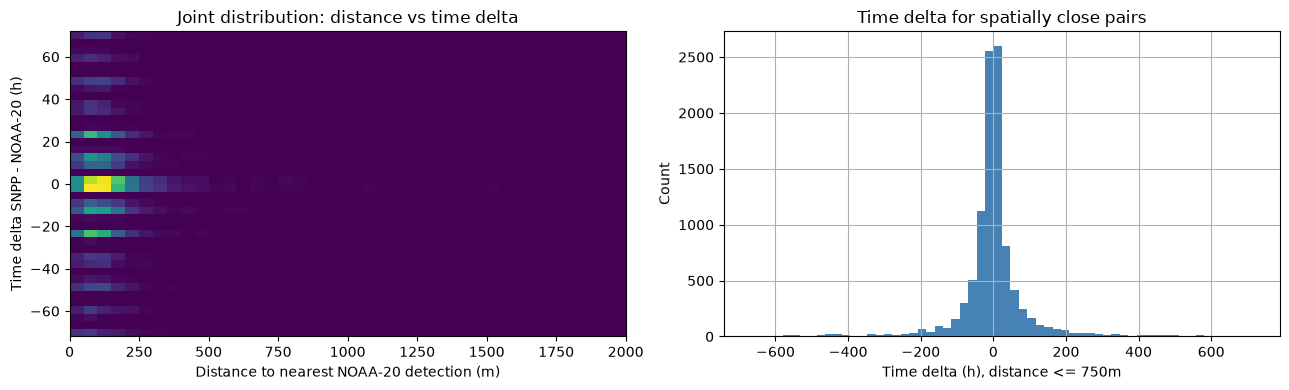

Distance to nearest NOAA-20 match (m):
count     10288.000000
mean        436.455304
std        2943.748605
min           0.000000
25%          65.563731
50%         107.942570
75%         168.168740
max      119725.197856
Name: dist_m, dtype: float64

For pairs within 750m, time delta (h):
count    9947.000000
mean       -0.268572
std       101.066074
min      -672.416667
25%       -22.833333
50%        -0.816667
75%        13.158333
max       719.783333
Name: time_delta_h, dtype: float64


In [22]:
matches = nearest_cross_product_match(hist_df, noaa20_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist2d(
    matches["dist_m"],
    matches["time_delta_h"],
    bins=(40, 40),
    range=[[0, 2000], [-72, 72]],
    cmap="viridis",
)
axes[0].set_xlabel("Distance to nearest NOAA-20 detection (m)")
axes[0].set_ylabel("Time delta SNPP - NOAA-20 (h)")
axes[0].set_title("Joint distribution: distance vs time delta")

close = matches[matches["dist_m"] <= 750]
close["time_delta_h"].hist(bins=60, ax=axes[1], color="steelblue", edgecolor="none")
axes[1].set_xlabel("Time delta (h), distance <= 750m")
axes[1].set_ylabel("Count")
axes[1].set_title("Time delta for spatially close pairs")

plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/cross_satellite_duplicates.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Distance to nearest NOAA-20 match (m):")
print(matches["dist_m"].describe())
print("\nFor pairs within 750m, time delta (h):")
print(close["time_delta_h"].describe())

There's a real cluster near (small distance, ~50 min) like expected, but also periodic bands at +/-12h, +/-24h, etc... Those bands are persistent fires getting matched to a different day's pass, not actual duplicates. Nearest neighbor in space ignores time, so it'll happily pair a SNPP detection with whatever NOAA-20 detection is spatially closest even if it's from the next day.

Stepping back though, the ~50 min offset isn't really a duplicate problem, it's just an earlier or later look at the same fire. So instead of picking a distance/time threshold to drop "duplicates," the better question is whether that second look actually changes enough to be worth keeping.

In [23]:
def match_within_window(df_a, df_b, max_time_h, crs="EPSG:32610", k=50):
    """Vectorized nearest-spatial-neighbor match, restricted to candidates
    within +/- max_time_h of each df_a detection.

    Queries the k nearest spatial neighbors in df_b for every df_a row, masks
    out candidates outside the time window, then keeps the closest surviving
    candidate. No per-row Python loop.
    """
    a_utm = gpd.GeoDataFrame(
        df_a,
        geometry=gpd.points_from_xy(df_a["longitude"], df_a["latitude"]),
        crs="EPSG:4326",
    ).to_crs(crs)
    b_utm = gpd.GeoDataFrame(
        df_b,
        geometry=gpd.points_from_xy(df_b["longitude"], df_b["latitude"]),
        crs="EPSG:4326",
    ).to_crs(crs)

    a_coords = np.column_stack([a_utm.geometry.x, a_utm.geometry.y])
    b_coords = np.column_stack([b_utm.geometry.x, b_utm.geometry.y])

    tree = cKDTree(b_coords)
    k = min(k, len(b_coords))
    dist_k, idx_k = tree.query(a_coords, k=k)

    a_time = df_a["acq_datetime"].values[:, None]
    b_time = df_b["acq_datetime"].values[idx_k]
    time_delta_h = (a_time - b_time) / np.timedelta64(1, "h")

    dist_k = np.where(np.abs(time_delta_h) <= max_time_h, dist_k, np.inf)

    best = np.argmin(dist_k, axis=1)
    row_idx = np.arange(len(df_a))

    matched = df_a.copy()
    matched["dist_m"] = dist_k[row_idx, best]
    matched["time_delta_h"] = time_delta_h[row_idx, best]
    matched["matched_frp"] = df_b["frp"].values[idx_k[row_idx, best]]
    matched["has_match"] = np.isfinite(matched["dist_m"])
    return matched

Matches within +/-90min: 9497 / 10288 (92.3%)

FRP delta (NOAA-20 - SNPP), matched pairs:
count    9497.000000
mean        2.431756
std        39.318947
min      -583.230000
25%        -1.190000
50%         0.230000
75%         2.280000
max       882.620000
Name: frp_delta, dtype: float64

FRP percent change:
count    9479.000000
mean        1.095903
std         7.187084
min        -1.000000
25%        -0.330679
50%         0.117241
75%         0.969223
max       347.488189
Name: frp_pct_change, dtype: float64


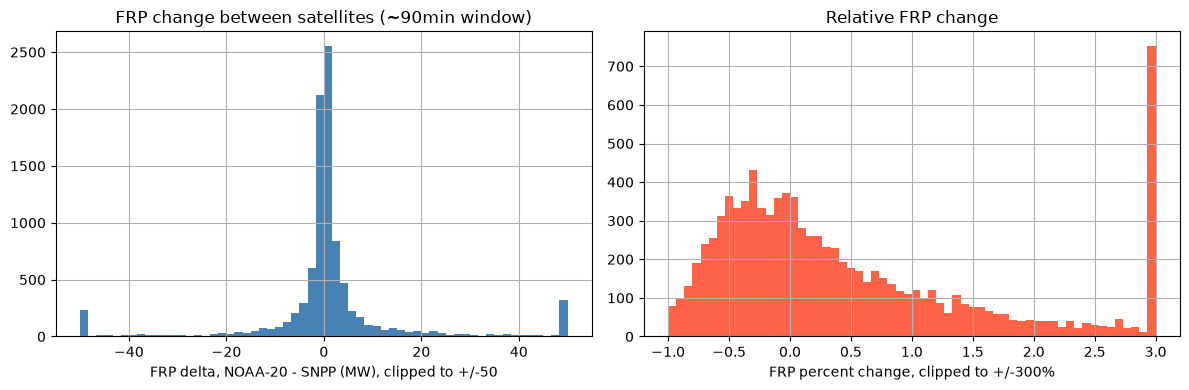

In [24]:
matches_90 = match_within_window(hist_df, noaa20_df, max_time_h=1.5)
matched = matches_90[matches_90["has_match"]].copy()
matched["frp_delta"] = matched["matched_frp"] - matched["frp"]
matched["frp_pct_change"] = matched["frp_delta"] / matched["frp"].replace(0, np.nan)

print(
    f"Matches within +/-90min: {len(matched)} / {len(matches_90)} ({len(matched)/len(matches_90):.1%})"
)
print("\nFRP delta (NOAA-20 - SNPP), matched pairs:")
print(matched["frp_delta"].describe())
print("\nFRP percent change:")
print(matched["frp_pct_change"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

matched["frp_delta"].clip(-50, 50).hist(
    bins=60, ax=axes[0], color="steelblue", edgecolor="none"
)
axes[0].set_xlabel("FRP delta, NOAA-20 - SNPP (MW), clipped to +/-50")
axes[0].set_title("FRP change between satellites (~90min window)")

matched["frp_pct_change"].clip(-3, 3).hist(
    bins=60, ax=axes[1], color="tomato", edgecolor="none"
)
axes[1].set_xlabel("FRP percent change, clipped to +/-300%")
axes[1].set_title("Relative FRP change")

plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/frp_delta_90min.png", dpi=150, bbox_inches="tight"
)
plt.show()

Restricted the match to +/-90 min (vectorized, time-masked nearest neighbor) and compared FRP between the two reads. 92.3% of SNPP detections have a NOAA-20 match in that window, so this is the normal case, not a rare overlap. Most pairs barely move, median delta is +0.23, IQR [-1.19, 2.28], but there's a real tail out to several hundred, meaning a meaningful chunk of fires change enough in 90 minutes for the second look to matter. Majority of fires seem to not change rapidly in this time frame, however, part of this project is to find the outliers, the fires that are in the tail that have potential to change rapidly.

Given that, both products should be used rather than treating NOAA-20 as redundant. Matched pairs should be treated as an update to the same hotspot rather than a new one, so cluster/feature counts don't get inflated, the actual merge logic is still TODO.

### pixel size variation

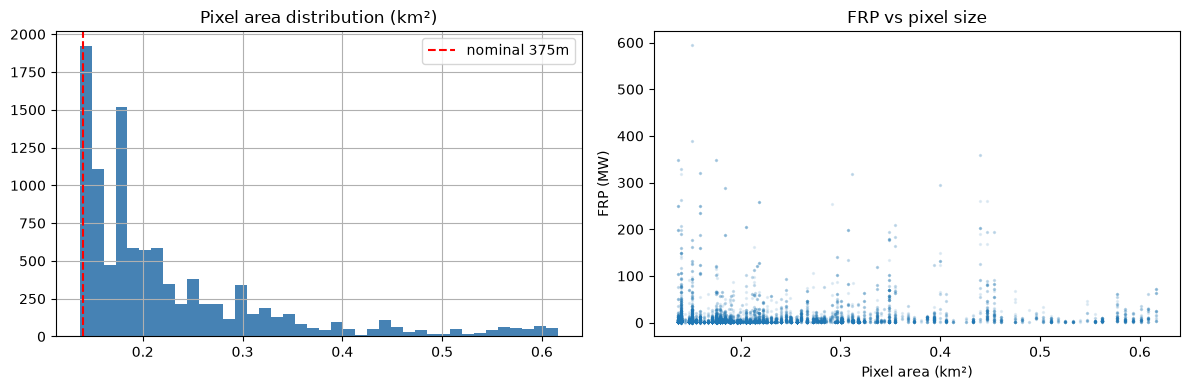

Fraction of pixels >0.5 km^2 (>~2x nadir size): 4.2%
Pixel area stats (km^2):


count    10288.000000
mean         0.227374
std          0.103841
min          0.136800
25%          0.151700
50%          0.189000
75%          0.260000
max          0.616200
Name: pixel_area_km2, dtype: float64

In [32]:
# Nominal pixel is 0.375km × 0.375km at nadir; grows toward swath edge
hist_df["pixel_area_km2"] = hist_df["scan"] * hist_df["track"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hist_df["pixel_area_km2"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Pixel area distribution (km²)")
axes[0].axvline(0.375**2, color="red", linestyle="--", label="nominal 375m")
axes[0].legend()

axes[1].scatter(hist_df["pixel_area_km2"], hist_df["frp"], alpha=0.1, s=2)
axes[1].set_xlabel("Pixel area (km²)")
axes[1].set_ylabel("FRP (MW)")
axes[1].set_title("FRP vs pixel size")

plt.tight_layout()
plt.savefig("plots/eda_historical_ics209/pixel_area.png", dpi=150, bbox_inches="tight")
plt.show()

oversized = (hist_df["pixel_area_km2"] > 0.5).mean()
print(f"Fraction of pixels >0.5 km^2 (>~2x nadir size): {oversized:.1%}")

print("Pixel area stats (km^2):")
hist_df["pixel_area_km2"].describe()

### geographic distribution

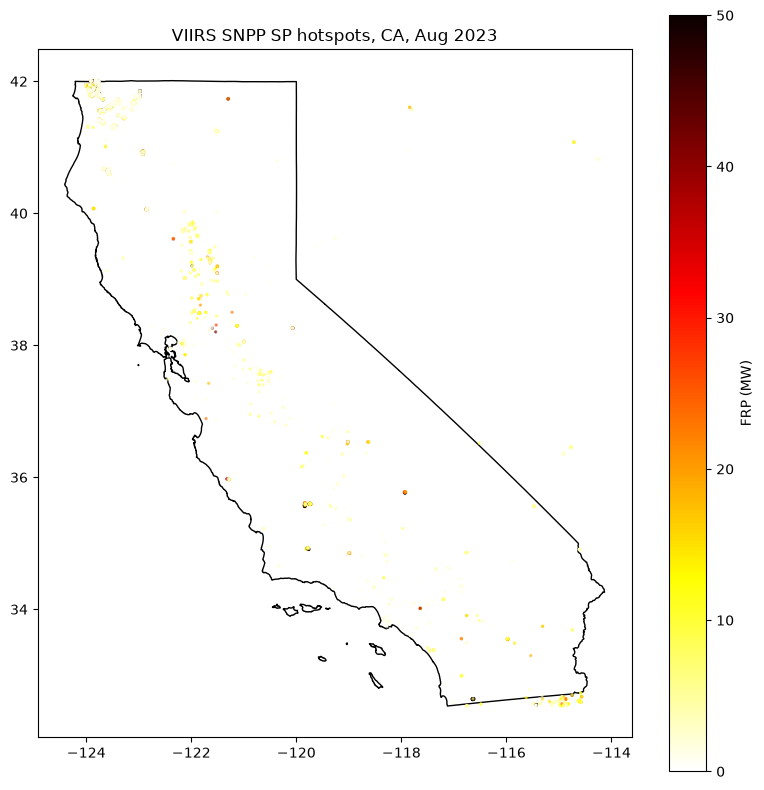

FRP distribution:


count    10288.000000
mean        11.273542
std         30.026313
min          0.000000
25%          1.360000
50%          3.290000
75%          8.330000
max        594.390000
Name: frp, dtype: float64

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))

# Load CA boundary (reproject to EPSG:4326)
resp = requests.get(
    "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_500k.zip",
    timeout=30,
)
states_gdf = gpd.read_file(BytesIO(resp.content))
ca = states_gdf[states_gdf["NAME"] == "California"].to_crs("EPSG:4326")

ca.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
hist_gdf.plot(
    ax=ax,
    column="frp",
    cmap="hot_r",
    markersize=2,
    alpha=0.5,
    vmin=0,
    vmax=50,
    legend=True,
    legend_kwds={"label": "FRP (MW)"},
)
ax.set_title("VIIRS SNPP SP hotspots, CA, Aug 2023")
plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/hotspot_map_ca.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("FRP distribution:")
hist_gdf["frp"].describe()

---
## ICS-209 Spot Check

want to answer: can we reliably match a known ICS-209 incident to FIRMS hotspots?

Using `data/ics209/ics209plus-wildfire/ics209-plus-wf_incidents_1999to2020.csv` (wildfire-only, cleaned incidents table).  
Note: ICS-209-PLUS covers 1999-2020, so the spot check uses 2019 instead of 2023.

In [34]:
ics = pd.read_csv(
    "../data/ics209/ics209plus-wildfire/ics209-plus-wf_incidents_1999to2020.csv",
    low_memory=False,
)
print(f"Total ICS-209-PLUS records: {len(ics)}")
print(
    f"CA wildfire rows: {((ics['POO_STATE'] == 'CA') & (ics['INCTYP_ABBREVIATION'] == 'WF')).sum()}"
)
print(f"Date range: {ics['DISCOVERY_DATE'].min()} -> {ics['DISCOVERY_DATE'].max()}")
ics.head()

Total ICS-209-PLUS records: 34622
CA wildfire rows: 3074
Date range: 1999-01-05 -> 2020-12-28 11:30:00


,Unnamed: 0,INCIDENT_ID,INCIDENT_NUMBER,INCIDENT_NAME,INCTYP_ABBREVIATION,FINAL_ACRES,CAUSE,COMPLEX,DISCOVERY_DATE,DISCOVERY_DOY,...,LRGST_FOD_LATITUDE,LRGST_FOD_LONGITUDE,LRGST_MTBS_FIRE_INFO,LRGST_FOD_COORDS,FIRED_ID,FIRED_ACRES,FIRED_SIMPLE_FSR,FIRED_MAX_GROWTH,FIRED_IG_LON,FIRED_IG_LAT
0,0,1999_AK-AIC-B251_MINTO,AK-AIC-B251,MINTO,WF,3800.0,H,False,1999-06-14,165.0,...,65.14950,-149.3691,AK6512614940419990613(MINTO),"(65.1495, -149.3691)",NaN,NaN,NaN,NaN,NaN,NaN
1,1,1999_AK-ARM-B222_DONNELLY FLATS,AK-ARM-B222,DONNELLY FLATS,WF,18000.0,H,False,1999-06-11,162.0,...,63.81630,-145.6690,AK6391514573119990611(DONNELLY FLATS),"(63.8163, -145.66899999999998)",NaN,NaN,NaN,NaN,NaN,NaN
2,2,1999_AK-GAD-B447_ROUNDABOUT MOUNTAIN,AK-GAD-B447,ROUNDABOUT MOUNTAIN,WF,6600.0,L,False,1999-07-11,192.0,...,65.58270,-156.4692,AK6558415646019990711(ROUNDABOUT MOUNTAIN),"(65.5827, -156.4692)",NaN,NaN,NaN,NaN,NaN,NaN
3,3,1999_AK-STA-901106_HELMAUR (CLARK WOLVERINE),AK-STA-901106,HELMAUR (CLARK WOLVERINE),WF,221.0,H,False,1999-05-18,138.0,...,61.67199,-149.0347,NaN,"(61.67199, -149.0347)",NaN,NaN,NaN,NaN,NaN,NaN
4,4,1999_AK-STA-901107_EKLUTNA,AK-STA-901107,EKLUTNA,WF,383.0,H,False,1999-05-18,138.0,...,61.43280,-149.2189,NaN,"(61.4328, -149.2189)",NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
ca_fires = ics[
    (ics["POO_STATE"] == "CA")
    & (ics["INCTYP_ABBREVIATION"] == "WF")
    & (ics["POO_LATITUDE"].notna())
    & (ics["POO_LONGITUDE"].notna())
].copy()

ca_fires["DISCOVERY_DATE"] = pd.to_datetime(
    ca_fires["DISCOVERY_DATE"], yearfirst=True, format="mixed"
)
ca_fires["fire_year"] = ca_fires["DISCOVERY_DATE"].dt.year

print(f"CA wildfires with coordinates: {len(ca_fires)}")
print(f"Null discovery dates: {ca_fires['DISCOVERY_DATE'].isna().sum()}")
print(ca_fires["fire_year"].value_counts().sort_index())

CA wildfires with coordinates: 3011
Null discovery dates: 0
fire_year
1999     88
2000     64
2001    121
2002    247
2003    248
2004    203
2005    185
2006    231
2007    180
2008    171
2009    140
2010    104
2011    119
2012    125
2014    106
2015    102
2016     85
2017    177
2018    103
2019     83
2020    129
Name: count, dtype: int64


In [36]:
# Use the largest CA wildfire in 2020 regardless of month, small fires produce
# too few VIIRS detections to validate the labeling strategy meaningfully
top_2020 = ca_fires[ca_fires["fire_year"] == 2020].sort_values(
    "FINAL_ACRES", ascending=False
)

print("Top 10 CA wildfires in 2020 by final acres:")
print(
    top_2020[
        [
            "INCIDENT_NAME",
            "DISCOVERY_DATE",
            "FINAL_ACRES",
            "POO_LATITUDE",
            "POO_LONGITUDE",
        ]
    ]
    .head(10)
    .to_string()
)

Top 10 CA wildfires in 2020 by final acres:
               INCIDENT_NAME      DISCOVERY_DATE  FINAL_ACRES  POO_LATITUDE  POO_LONGITUDE
34326                    DOE 2020-08-16 10:48:00     450842.6     39.765390    -122.673300
34310  SCU LIGHTNING COMPLEX 2020-08-16 07:56:00     396624.0     37.423900    -121.567700
34415            SHF ELKHORN 2020-08-29 13:55:00     391493.0     40.201810    -122.998300
34402                  CREEK 2020-09-04 20:33:00     379895.0     37.201000    -119.271600
34267  LNU LIGHTNING COMPLEX 2020-08-17 13:57:00     363220.0     38.597446    -122.997930
34223                 CASTLE 2020-08-19 09:15:00     174178.0     36.163020    -118.447950
34426                 SLATER 2020-09-08 08:43:00     157270.0     41.858026    -123.353584
34222                  DOLAN 2020-08-18 22:04:00     124924.0     36.123280    -121.601600
34447                 BOBCAT 2020-09-06 14:21:00     115997.0     34.248120    -117.959100
34312      CZU AUG LIGHTNING 2020-08-16 08:41:

In [37]:
target = top_2020.iloc[0]
print(f"Target: {target['INCIDENT_NAME']}")
print(f"Discovered: {target['DISCOVERY_DATE']}")
print(f"Size: {target['FINAL_ACRES']:.0f} acres")
print(f"Origin: {target['POO_LATITUDE']:.4f}, {target['POO_LONGITUDE']:.4f}")

Target: DOE
Discovered: 2020-08-16 10:48:00
Size: 450843 acres
Origin: 39.7654, -122.6733


In [38]:
lat0, lon0 = target["POO_LATITUDE"], target["POO_LONGITUDE"]
pad = 1.0
target_bbox = f"{lon0-pad:.4f},{lat0-pad:.4f},{lon0+pad:.4f},{lat0+pad:.4f}"
target_start = target["DISCOVERY_DATE"].date().isoformat()

print(f"Fetching FIRMS for bbox {target_bbox}, 20 days from {target_start}...")
chunks = []
start = date.fromisoformat(target_start)
for _ in range(4):  # 4 × 5 days = 20 days
    df = fetch_firms_chunk(PRODUCT, target_bbox, start.isoformat(), 5, MAP_KEY)
    chunks.append(df)
    start += timedelta(days=5)

target_df = pd.concat(chunks, ignore_index=True)
target_df["acq_datetime"] = pd.to_datetime(
    target_df["acq_date"].astype(str)
    + " "
    + target_df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    utc=True,
)
target_gdf = gpd.GeoDataFrame(
    target_df,
    geometry=gpd.points_from_xy(target_df["longitude"], target_df["latitude"]),
    crs="EPSG:4326",
)
print(f"Hotspots fetched: {len(target_gdf)}")

Fetching FIRMS for bbox -123.6733,38.7654,-121.6733,40.7654, 20 days from 2020-08-16...
Hotspots fetched: 24332


In [40]:
# distance from each hotspot to ICS-209 origin point
origin_gdf = gpd.GeoDataFrame(geometry=[Point(lon0, lat0)], crs="EPSG:4326").to_crs(
    "EPSG:32610"
)

target_utm = target_gdf.to_crs("EPSG:32610")
target_gdf["dist_to_origin_km"] = (
    target_utm.geometry.distance(origin_gdf.geometry.iloc[0]) / 1000
)

print("Distance distribution from hotspots to ICS-209 origin:")
print(target_gdf["dist_to_origin_km"].describe().round(1))

for threshold in [5, 10, 20, 50]:
    n = (target_gdf["dist_to_origin_km"] <= threshold).sum()
    print(f"Within {threshold} km: {n} hotspots ({n/len(target_gdf):.1%})")

Distance distribution from hotspots to ICS-209 origin:
count    24332.0
mean        28.8
std         22.4
min          0.1
25%         15.9
50%         22.9
75%         33.4
max        118.3
Name: dist_to_origin_km, dtype: float64
Within 5 km: 624 hotspots (2.6%)
Within 10 km: 2269 hotspots (9.3%)
Within 20 km: 9586 hotspots (39.4%)
Within 50 km: 21572 hotspots (88.7%)


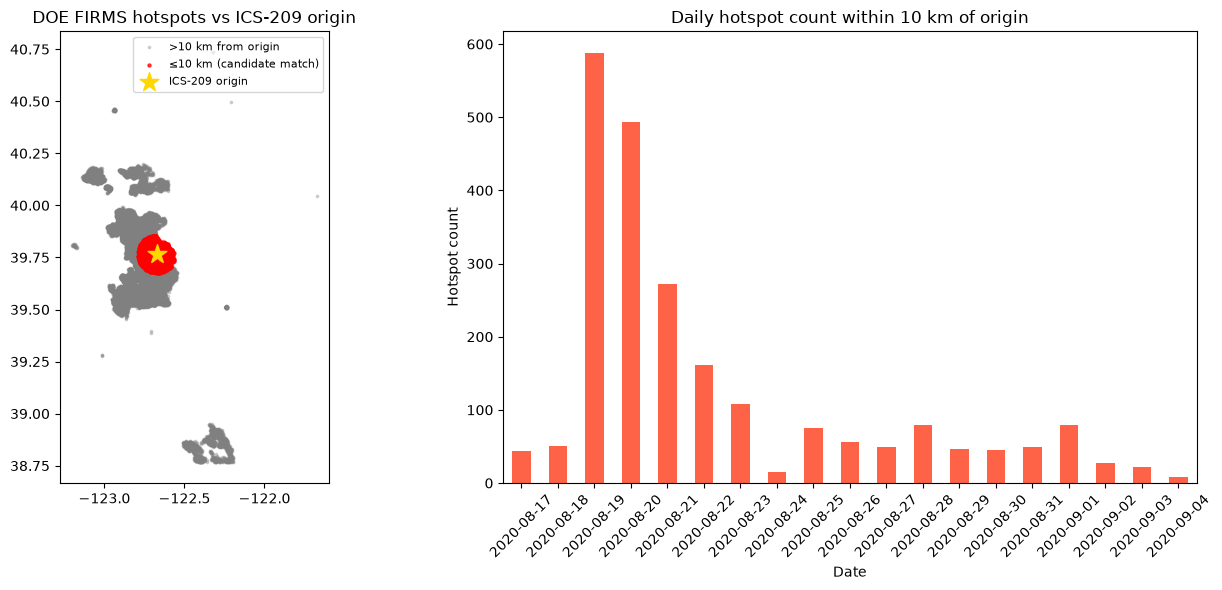

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
within_10 = target_gdf[target_gdf["dist_to_origin_km"] <= 10]
beyond_10 = target_gdf[target_gdf["dist_to_origin_km"] > 10]
beyond_10.plot(ax=ax, color="gray", markersize=3, alpha=0.3, label=">10 km from origin")
within_10.plot(
    ax=ax, color="red", markersize=5, alpha=0.7, label="≤10 km (candidate match)"
)
ax.scatter(
    [lon0], [lat0], marker="*", s=200, color="gold", zorder=5, label="ICS-209 origin"
)
ax.set_title(f"{target['INCIDENT_NAME']} FIRMS hotspots vs ICS-209 origin")
ax.legend(fontsize=8)

ax2 = axes[1]
daily_matched = within_10.groupby("acq_date").size()
daily_matched.plot(ax=ax2, kind="bar", color="tomato", edgecolor="none")
ax2.set_title("Daily hotspot count within 10 km of origin")
ax2.set_xlabel("Date")
ax2.set_ylabel("Hotspot count")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/hotspots_vs_origin.png", dpi=150, bbox_inches="tight"
)
plt.show()

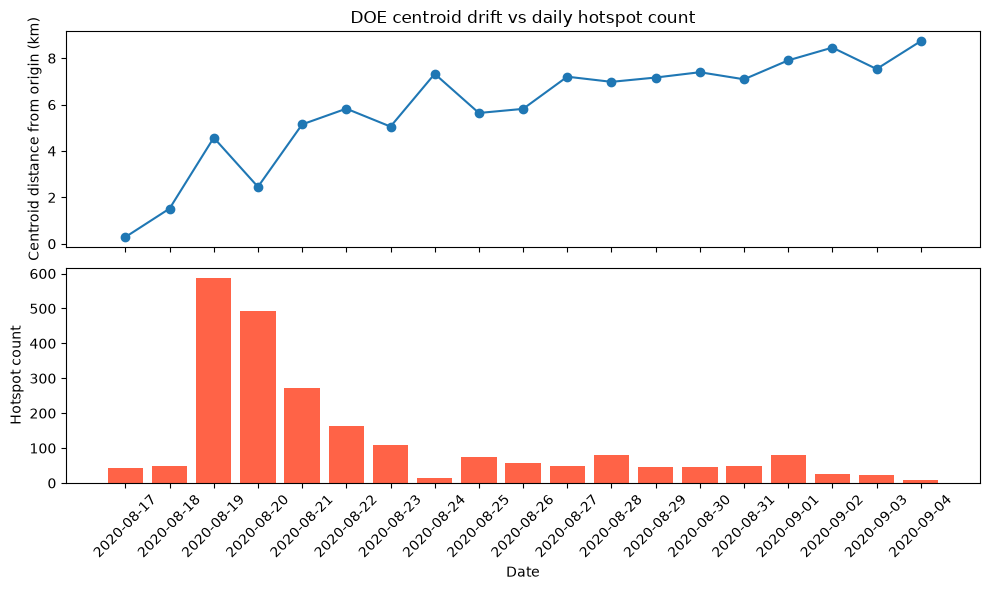

Max centroid drift from origin: 8.7 km
  acq_date  centroid_dist_km   n
2020-08-17          0.290775  44
2020-08-18          1.518797  50
2020-08-19          4.573856 588
2020-08-20          2.455455 493
2020-08-21          5.147763 272
2020-08-22          5.825761 162
2020-08-23          5.053194 108
2020-08-24          7.326441  15
2020-08-25          5.639696  75
2020-08-26          5.816745  56
2020-08-27          7.204043  49
2020-08-28          6.982075  80
2020-08-29          7.167443  46
2020-08-30          7.396690  45
2020-08-31          7.091977  49
2020-09-01          7.908294  80
2020-09-02          8.458699  27
2020-09-03          7.534987  22
2020-09-04          8.737036   8


In [44]:
# look at centroid drift: does the cluster centroid stay near the ICS-209 origin over time?
# Use only hotspots within 10km (the candidate fire cluster), not all bbox hotspots
fire_utm = within_10.to_crs("EPSG:32610").copy()
fire_utm["x"] = fire_utm.geometry.x
fire_utm["y"] = fire_utm.geometry.y

daily_centroids = fire_utm.groupby("acq_date")[["x", "y"]].mean().reset_index()
daily_centroids["n"] = fire_utm.groupby("acq_date").size().values

origin_utm = origin_gdf.geometry.iloc[0]
daily_centroids["centroid_dist_km"] = (
    (daily_centroids["x"] - origin_utm.x) ** 2
    + (daily_centroids["y"] - origin_utm.y) ** 2
) ** 0.5 / 1000

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(
    daily_centroids["acq_date"], daily_centroids["centroid_dist_km"], marker="o"
)
axes[0].set_ylabel("Centroid distance from origin (km)")
axes[0].set_title(f"{target['INCIDENT_NAME']} centroid drift vs daily hotspot count")

axes[1].bar(
    daily_centroids["acq_date"], daily_centroids["n"], color="tomato", edgecolor="none"
)
axes[1].set_ylabel("Hotspot count")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/centroid_drift.png", dpi=150, bbox_inches="tight"
)
plt.show()

print(
    f"Max centroid drift from origin: {daily_centroids['centroid_dist_km'].max():.1f} km"
)
print(daily_centroids[["acq_date", "centroid_dist_km", "n"]].to_string(index=False))

### Is the hotspot cluster one large fire or multiple adjacent incidents?

The 10km circle is an arbitrary threshold. For large fires the burned area extends well beyond the ignition point, and for dense multi-fire regions multiple ICS-209 incidents may share the same bbox.

ICS-209 incidents in bbox during fetch window: 8
INCIDENT_NAME      DISCOVERY_DATE  FINAL_ACRES  dist_to_target_km
          DOE 2020-08-16 10:48:00     450842.6           0.000000
          ELK 2020-08-16 10:02:00        727.0          27.769150
         HULL 2020-08-19 08:33:00          0.1          34.148383
        CREEK 2020-08-18 17:46:00        820.0          45.927643
        SITES 2020-08-02 18:15:00        560.0          52.751041
  SHF ELKHORN 2020-08-29 13:55:00     391493.0          55.823379
      PLATINA 2020-07-19 17:46:00        340.0          74.757547
       SPRING 2020-08-17 17:57:00        230.0          79.951149


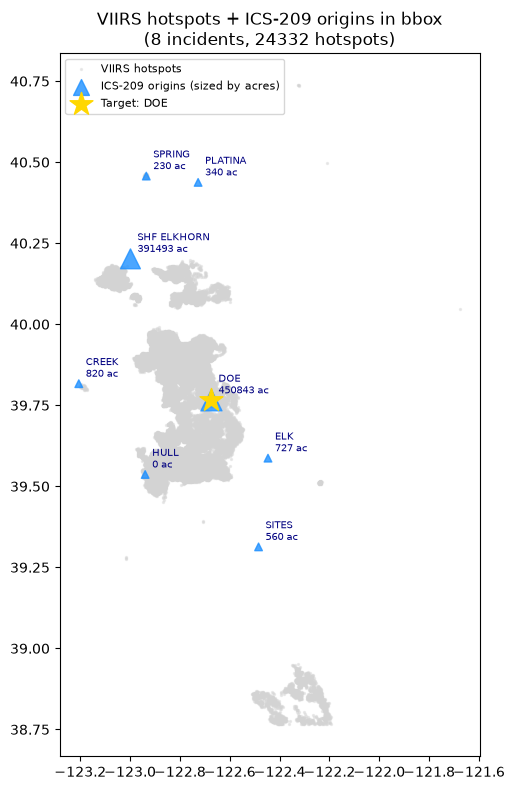

In [45]:
fetch_start = pd.Timestamp(target["DISCOVERY_DATE"])
fetch_end = fetch_start + pd.Timedelta(days=20)

nearby_incidents = ca_fires[
    ca_fires["POO_LATITUDE"].between(lat0 - pad, lat0 + pad)
    & ca_fires["POO_LONGITUDE"].between(lon0 - pad, lon0 + pad)
    & (ca_fires["DISCOVERY_DATE"] >= fetch_start - pd.Timedelta(days=30))
    & (ca_fires["DISCOVERY_DATE"] <= fetch_end)
].copy()

nearby_incidents["dist_to_target_km"] = (
    gpd.GeoDataFrame(
        nearby_incidents,
        geometry=gpd.points_from_xy(
            nearby_incidents["POO_LONGITUDE"], nearby_incidents["POO_LATITUDE"]
        ),
        crs="EPSG:4326",
    )
    .to_crs("EPSG:32610")
    .geometry.distance(origin_gdf.geometry.iloc[0])
    / 1000
)

print(f"ICS-209 incidents in bbox during fetch window: {len(nearby_incidents)}")
print(
    nearby_incidents[
        ["INCIDENT_NAME", "DISCOVERY_DATE", "FINAL_ACRES", "dist_to_target_km"]
    ]
    .sort_values("dist_to_target_km")
    .to_string(index=False)
)

# Plot: all hotspots + every nearby ICS-209 origin
fig, ax = plt.subplots(figsize=(9, 8))
target_gdf.plot(
    ax=ax, color="lightgray", markersize=2, alpha=0.4, label="VIIRS hotspots"
)

# ax.scatter() is needed for variable marker sizes — geopandas .plot() only accepts
# a scalar for markersize when no column is set, so variable sizes silently break there
max_acres = nearby_incidents["FINAL_ACRES"].fillna(0).max()
sizes = (nearby_incidents["FINAL_ACRES"].fillna(0) / max_acres * 200 + 30).values
ax.scatter(
    nearby_incidents["POO_LONGITUDE"].values,
    nearby_incidents["POO_LATITUDE"].values,
    s=sizes,
    c="dodgerblue",
    alpha=0.8,
    marker="^",
    zorder=4,
    label="ICS-209 origins (sized by acres)",
)

ax.scatter(
    [lon0],
    [lat0],
    marker="*",
    s=300,
    color="gold",
    zorder=5,
    label=f"Target: {target['INCIDENT_NAME']}",
)

for _, row in nearby_incidents.iterrows():
    ax.annotate(
        f"{row['INCIDENT_NAME']}\n{row['FINAL_ACRES']:.0f} ac",
        xy=(row["POO_LONGITUDE"], row["POO_LATITUDE"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
        color="navy",
    )

ax.set_title(
    f"VIIRS hotspots + ICS-209 origins in bbox\n"
    f"({len(nearby_incidents)} incidents, {len(target_gdf)} hotspots)"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/colocated_incidents.png", dpi=150, bbox_inches="tight"
)
plt.show()

Spatial clusters found (epsilon=1km, min_samples=3): 13
Noise points (unclustered): 8

Origin falls in cluster 0
Cluster hotspot count: 18884
Cluster spatial extent: 38.5 km from origin
Naive 10km circle: 2269 hotspots


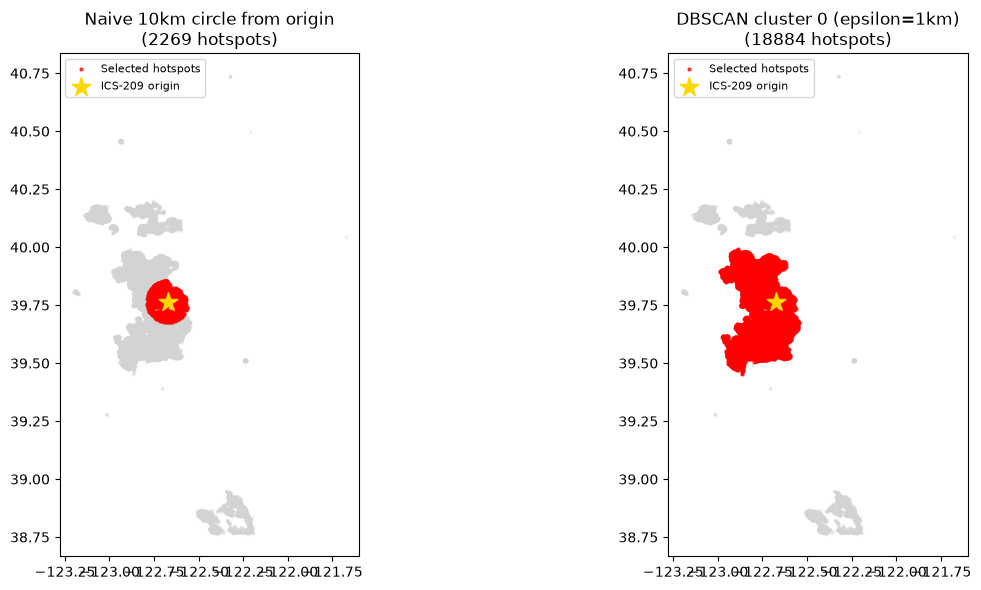

In [46]:
# Spatial DBSCAN on all hotspots in the bbox (no time dimension yet)
target_utm = target_gdf.to_crs("EPSG:32610")
coords = np.column_stack([target_utm.geometry.x, target_utm.geometry.y])

# starting with a largeish epsilon to find broad clusters
db = DBSCAN(eps=1000, min_samples=3).fit(coords)
target_gdf = target_gdf.copy()
target_gdf["cluster"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"Spatial clusters found (epsilon=1km, min_samples=3): {n_clusters}")
print(f"Noise points (unclustered): {(db.labels_ == -1).sum()}")

# find which cluster contains the ICS-209 origin
nearest_idx = target_gdf["dist_to_origin_km"].idxmin()
origin_cluster = target_gdf.loc[nearest_idx, "cluster"]
origin_cluster_gdf = target_gdf[target_gdf["cluster"] == origin_cluster]

print(f"\nOrigin falls in cluster {origin_cluster}")
print(f"Cluster hotspot count: {len(origin_cluster_gdf)}")
print(
    f"Cluster spatial extent: {origin_cluster_gdf['dist_to_origin_km'].max():.1f} km from origin"
)
print(
    f"Naive 10km circle: {len(target_gdf[target_gdf['dist_to_origin_km'] <= 10])} hotspots"
)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, title, highlight in [
    (
        axes[0],
        "Naive 10km circle from origin",
        target_gdf[target_gdf["dist_to_origin_km"] <= 10],
    ),
    (axes[1], f"DBSCAN cluster {origin_cluster} (epsilon=1km)", origin_cluster_gdf),
]:
    outside = target_gdf[~target_gdf.index.isin(highlight.index)]
    outside.plot(ax=ax, color="lightgray", markersize=2, alpha=0.3)
    highlight.plot(
        ax=ax, color="red", markersize=4, alpha=0.7, label="Selected hotspots"
    )
    ax.scatter(
        [lon0],
        [lat0],
        marker="*",
        s=200,
        color="gold",
        zorder=5,
        label="ICS-209 origin",
    )
    ax.set_title(f"{title}\n({len(highlight)} hotspots)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/dbscan_vs_naive.png", dpi=150, bbox_inches="tight"
)
plt.show()

Total DBSCAN clusters (excluding noise): 13
No ICS-209 within  5 km: 11 clusters (84.6%) -> would be unlabeled or false negative
No ICS-209 within 10 km: 10 clusters (76.9%) -> would be unlabeled or false negative
No ICS-209 within 20 km: 6 clusters (46.2%) -> would be unlabeled or false negative
No ICS-209 within 50 km: 3 clusters (23.1%) -> would be unlabeled or false negative


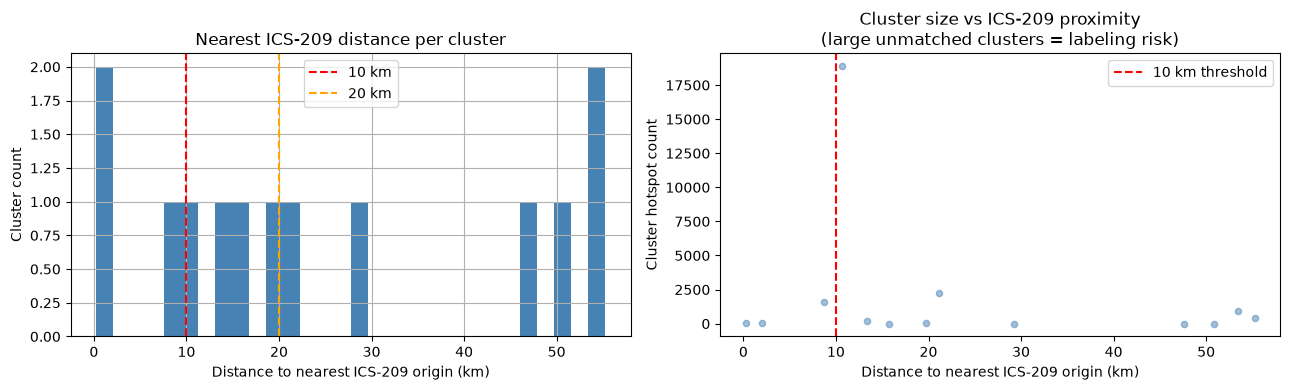

In [48]:
# For each DBSCAN cluster, compute centroid then find its nearest ICS-209 incident
cluster_centroids = (
    target_gdf[target_gdf["cluster"] != -1]
    .to_crs("EPSG:32610")
    .assign(x=lambda g: g.geometry.x, y=lambda g: g.geometry.y)
    .groupby("cluster")
    .agg(x=("x", "mean"), y=("y", "mean"), n_hotspots=("x", "count"))
    .reset_index()
)

# use nearby incidents
nearby_utm = gpd.GeoDataFrame(
    nearby_incidents,
    geometry=gpd.points_from_xy(
        nearby_incidents["POO_LONGITUDE"], nearby_incidents["POO_LATITUDE"]
    ),
    crs="EPSG:4326",
).to_crs("EPSG:32610")

cluster_centroids["nearest_ics_km"] = cluster_centroids.apply(
    lambda row: nearby_utm.geometry.distance(Point(row["x"], row["y"])).min() / 1000,
    axis=1,
)

print(f"Total DBSCAN clusters (excluding noise): {len(cluster_centroids)}")
for threshold in [5, 10, 20, 50]:
    no_match = (cluster_centroids["nearest_ics_km"] > threshold).sum()
    pct = no_match / len(cluster_centroids)
    print(
        f"No ICS-209 within {threshold:2d} km: {no_match} clusters ({pct:.1%}) -> would be unlabeled or false negative"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cluster_centroids["nearest_ics_km"].hist(
    bins=30, ax=axes[0], color="steelblue", edgecolor="none"
)
for thresh, color in [(10, "red"), (20, "orange")]:
    axes[0].axvline(thresh, color=color, linestyle="--", label=f"{thresh} km")
axes[0].set_xlabel("Distance to nearest ICS-209 origin (km)")
axes[0].set_ylabel("Cluster count")
axes[0].set_title("Nearest ICS-209 distance per cluster")
axes[0].legend()

axes[1].scatter(
    cluster_centroids["nearest_ics_km"],
    cluster_centroids["n_hotspots"],
    alpha=0.5,
    s=20,
    color="steelblue",
)
axes[1].axvline(10, color="red", linestyle="--", label="10 km threshold")
axes[1].set_xlabel("Distance to nearest ICS-209 origin (km)")
axes[1].set_ylabel("Cluster hotspot count")
axes[1].set_title(
    "Cluster size vs ICS-209 proximity\n(large unmatched clusters = labeling risk)"
)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/cluster_ics_distance.png", dpi=150, bbox_inches="tight"
)
plt.show()

### look at VIIRS `type` column

In [49]:
# VIIRS type: 0=vegetation fire, 1=active volcano, 2=other static land source, 3=offshore
print("Type distribution in target bbox:")
print(target_gdf["type"].value_counts().sort_index())

non_veg = (target_gdf["type"] != 0).sum()
print(
    f"Non-vegetation hotspots removed by type=0 filter: {non_veg} ({non_veg/len(target_gdf):.1%})"
)
print(f"Remaining after filter: {len(target_gdf) - non_veg}")

# Check if any non-vegetation detections ended up inside the origin cluster
non_veg_in_cluster = origin_cluster_gdf[origin_cluster_gdf["type"] != 0]
print(f"\nNon-vegetation detections inside origin cluster: {len(non_veg_in_cluster)}")

# Also check in the full historical sample
print("\nType distribution in Aug 2023 statewide sample:")
print(hist_df["type"].value_counts().sort_index())

Type distribution in target bbox:
type
0    24332
Name: count, dtype: int64
Non-vegetation hotspots removed by type=0 filter: 0 (0.0%)
Remaining after filter: 24332

Non-vegetation detections inside origin cluster: 0

Type distribution in Aug 2023 statewide sample:
type
0    9599
2     689
Name: count, dtype: int64


### ICS-209 reporting lag vs FIRMS first detection

In [50]:
# Compare FIRMS first detection to ICS-209 DISCOVERY_DATE for each nearby incident.
# ICS-209 DISCOVERY_DATE is local time and acq_datetime is UTC.
# California PDT = UTC-7, so UTC = local + 7h.
CA_UTC_OFFSET_H = 7

lags = []
for _, inc in nearby_incidents.iterrows():
    inc_origin = (
        gpd.GeoDataFrame(
            geometry=[Point(inc["POO_LONGITUDE"], inc["POO_LATITUDE"])], crs="EPSG:4326"
        )
        .to_crs("EPSG:32610")
        .geometry.iloc[0]
    )

    dists = target_gdf.to_crs("EPSG:32610").geometry.distance(inc_origin) / 1000
    nearby_hs = target_gdf[dists <= 10]

    if len(nearby_hs) == 0:
        continue

    first_firms = nearby_hs["acq_datetime"].min()  # UTC-aware

    # convert ICS-209 local time -> UTC by adding offset, then localize
    ics_local = pd.Timestamp(inc["DISCOVERY_DATE"])
    ics_utc = (ics_local + pd.Timedelta(hours=CA_UTC_OFFSET_H)).tz_localize("UTC")

    # Positive lag: ICS-209 reported AFTER FIRMS first detected (FIRMS was faster)
    # Negative lag: ICS-209 reported BEFORE FIRMS detected (fire caught between passes)
    lag_h = (ics_utc - first_firms).total_seconds() / 3600

    lags.append(
        {
            "incident": inc["INCIDENT_NAME"],
            "final_acres": inc["FINAL_ACRES"],
            "firms_first_utc": first_firms,
            "ics_discovery_utc": ics_utc,
            "lag_hours": lag_h,
            "n_hotspots_within_10km": len(nearby_hs),
        }
    )

lag_df = pd.DataFrame(lags)
lag_df[
    [
        "incident",
        "final_acres",
        "firms_first_utc",
        "ics_discovery_utc",
        "lag_hours",
        "n_hotspots_within_10km",
    ]
].to_string(index=False)
display(lag_df)
print(f"Median lag: {lag_df['lag_hours'].median():.1f} h")

,incident,final_acres,firms_first_utc,ics_discovery_utc,lag_hours,n_hotspots_within_10km
0,CREEK,820.0,2020-08-19 10:20:00+00:00,2020-08-19 00:46:00+00:00,-9.566667,24
1,HULL,0.1,2020-08-19 10:20:00+00:00,2020-08-19 15:33:00+00:00,5.216667,2507
2,SPRING,230.0,2020-08-19 21:43:00+00:00,2020-08-18 00:57:00+00:00,-44.766667,36
3,DOE,450842.6,2020-08-17 09:17:00+00:00,2020-08-16 17:48:00+00:00,-15.483333,2269
4,SHF ELKHORN,391493.0,2020-08-19 21:43:00+00:00,2020-08-29 20:55:00+00:00,239.200000,1092


Median lag: -9.6 h


- Positive lag = FIRMS detected fire before ICS-209 discovery (satellite faster which is good for early warning)
- Negative lag = ICS-209 reported fire before FIRMS detected it (fire caught between satellite passes)

### look at class imbalance

Classify each DBSCAN cluster as positive, negative, or unlabeled
- Positive  : nearest ICS-209 within 10km (declared incident)
- Unlabeled : nearest ICS-209 10-50km (ambiguous —> real fire, no clear match)
- Negative  : nearest ICS-209 > 50km (likely prescribed burn / sub-threshold fire)

10km is arbritrary threshold picked, would need to do actual tuning on this, but for now this value will suffice

Total clusters: 13
Positive (<=10 km):    3  (23.1%)
Unlabeled (10–50 km):    7  (53.8%)
Negative (>50 km):    3  (23.1%)

Among usable (pos + neg): positive rate = 50.0%
Implied XGBoost scale_pos_weight: 1.0


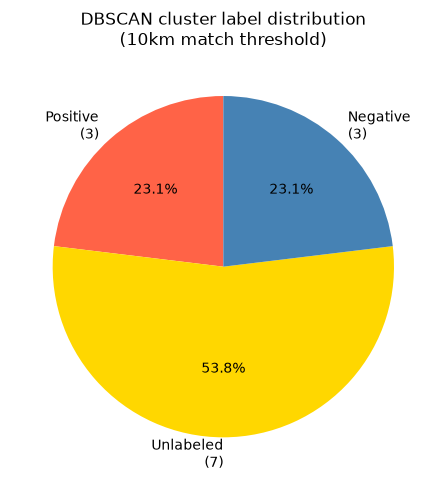

In [55]:
pos = cluster_centroids[cluster_centroids["nearest_ics_km"] <= 10]
ambig = cluster_centroids[
    (cluster_centroids["nearest_ics_km"] > 10)
    & (cluster_centroids["nearest_ics_km"] <= 50)
]
neg = cluster_centroids[cluster_centroids["nearest_ics_km"] > 50]

total = len(cluster_centroids)
print(f"Total clusters: {total}")
print(f"Positive (<=10 km): {len(pos):4d}  ({len(pos)/total:.1%})")
print(f"Unlabeled (10–50 km): {len(ambig):4d}  ({len(ambig)/total:.1%})")
print(f"Negative (>50 km): {len(neg):4d}  ({len(neg)/total:.1%})")

usable = len(pos) + len(neg)
pos_rate = len(pos) / usable if usable > 0 else 0
print(f"\nAmong usable (pos + neg): positive rate = {pos_rate:.1%}")
print(
    f"Implied XGBoost scale_pos_weight: {len(neg)/len(pos):.1f}"
    if len(pos) > 0
    else "No positives found"
)

# pie chart
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [len(pos), len(ambig), len(neg)],
    labels=[
        f"Positive\n({len(pos)})",
        f"Unlabeled\n({len(ambig)})",
        f"Negative\n({len(neg)})",
    ],
    colors=["tomato", "gold", "steelblue"],
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title("DBSCAN cluster label distribution\n(10km match threshold)")
plt.tight_layout()
plt.savefig(
    "plots/eda_historical_ics209/cluster_label_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### ST-DBSCAN

Spatial DBSCAN clusters hotspots regardless of when they burned. A fire that went cold and re-ignited days later would form one spatial cluster but should be two separate events. Splitting each spatial cluster at detection gaps > `temporal_eps` approximates the ST-DBSCAN temporal dimension without a custom metric.

In [58]:
TEMPORAL_EPS_H = 48  # arbirtrary threshold picked for EDA


def split_cluster_by_time(group, gap_hours):
    group = group.sort_values("acq_datetime").copy()
    group["gap_h"] = group["acq_datetime"].diff().dt.total_seconds() / 3600
    group["subcl"] = (group["gap_h"] > gap_hours).cumsum()
    return group


st_parts = []
for cluster_id, group in target_gdf[target_gdf["cluster"] != -1].groupby("cluster"):
    split = split_cluster_by_time(group, TEMPORAL_EPS_H)
    split["st_cluster"] = cluster_id * 1000 + split["subcl"]
    st_parts.append(split)

st_df = pd.concat(st_parts, ignore_index=True)

n_spatial = target_gdf["cluster"].nunique() - (
    1 if -1 in target_gdf["cluster"].values else 0
)
n_st = st_df["st_cluster"].nunique()
splits = n_st - n_spatial

print(f"Spatial clusters: {n_spatial}")
print(f"ST clusters (temporal_eps={TEMPORAL_EPS_H}h): {n_st}")
print(f"Clusters split by temporal gap: {splits} ({splits/n_spatial:.1%})")

# show which clusters were split and the gap that caused it
split_summary = (
    st_df.groupby("st_cluster")
    .agg(
        start=("acq_datetime", "min"),
        end=("acq_datetime", "max"),
        n=("acq_datetime", "count"),
    )
    .reset_index()
)
split_summary["spatial_cluster"] = split_summary["st_cluster"] // 1000
multi = split_summary[
    split_summary.groupby("spatial_cluster")["st_cluster"].transform("count") > 1
]
if len(multi) > 0:
    print(f"\nSplit cluster details:")
    print(
        multi[["spatial_cluster", "st_cluster", "start", "end", "n"]].to_string(
            index=False
        )
    )
else:
    print(
        "\nNo clusters split, all spatial clusters are temporally continuous within 48h"
    )

Spatial clusters: 13
ST clusters (temporal_eps=48h): 16
Clusters split by temporal gap: 3 (23.1%)

Split cluster details:
 spatial_cluster  st_cluster                     start                       end   n
               5        5000 2020-08-19 10:20:00+00:00 2020-08-25 21:30:00+00:00 414
               5        5001 2020-08-28 20:33:00+00:00 2020-08-28 20:33:00+00:00   1
              10       10000 2020-08-19 10:20:00+00:00 2020-08-20 10:01:00+00:00   2
              10       10001 2020-08-25 10:07:00+00:00 2020-08-25 10:07:00+00:00   1
              10       10002 2020-08-30 10:14:00+00:00 2020-08-30 10:14:00+00:00   1


###  FRP changes over time

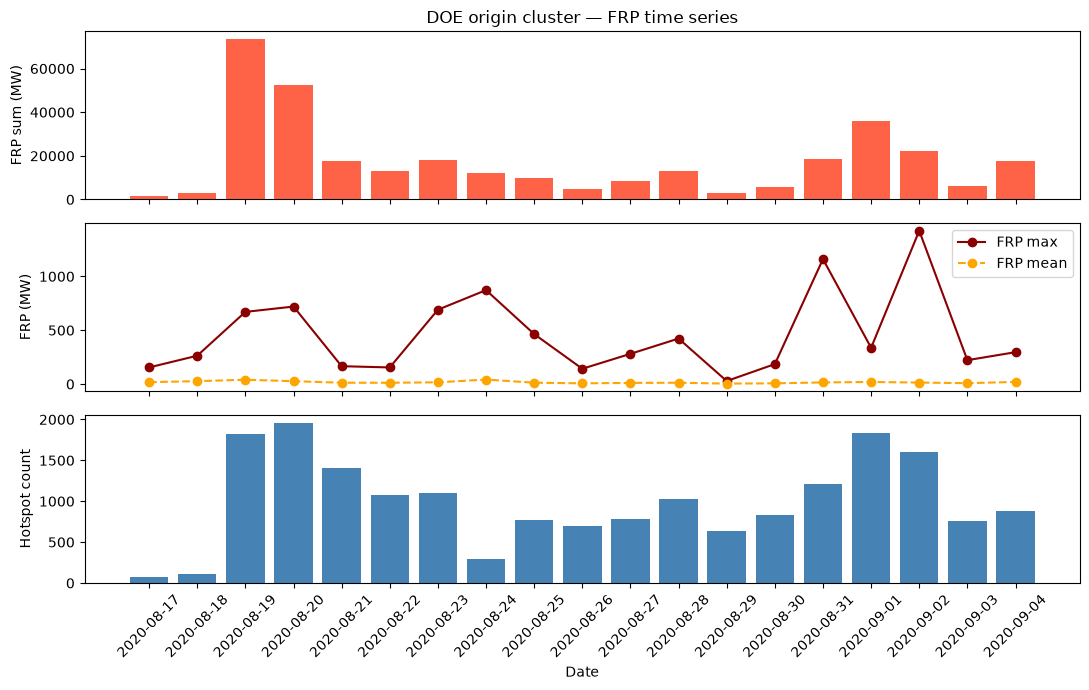

  acq_date  frp_sum  frp_max  frp_mean  n_hotspots
2020-08-17  1413.68   154.56 17.894684          79
2020-08-18  2961.75   263.48 26.925000         110
2020-08-19 73416.06   670.48 40.360671        1819
2020-08-20 52654.64   719.87 26.892053        1958
2020-08-21 17732.18   166.13 12.567101        1411
2020-08-22 13056.83   154.53 12.078474        1081
2020-08-23 18136.66   690.74 16.443028        1103
2020-08-24 12365.89   872.45 41.918271         295
2020-08-25  9894.73   464.27 12.817008         772
2020-08-26  4803.25   142.24  6.891320         697
2020-08-27  8423.84   280.89 10.785967         781
2020-08-28 12930.30   422.83 12.529360        1032
2020-08-29  2752.43    28.41  4.287274         642
2020-08-30  5713.77   185.46  6.909033         827
2020-08-31 18441.06  1160.79 15.240545        1210
2020-09-01 35835.38   337.20 19.539466        1834
2020-09-02 22375.61  1423.98 14.002259        1598
2020-09-03  6333.45   222.01  8.333487         760
2020-09-04 17482.03   296.30 19

In [63]:
frp_daily = (
    origin_cluster_gdf.groupby("acq_date")
    .agg(
        frp_sum=("frp", "sum"),
        frp_max=("frp", "max"),
        frp_mean=("frp", "mean"),
        n_hotspots=("frp", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].bar(
    frp_daily["acq_date"],
    frp_daily["frp_sum"],
    color="tomato",
    edgecolor="none",
    label="FRP sum",
)
axes[0].set_ylabel("FRP sum (MW)")
axes[0].set_title(f"{target['INCIDENT_NAME']} origin cluster — FRP time series")

axes[1].plot(
    frp_daily["acq_date"],
    frp_daily["frp_max"],
    marker="o",
    color="darkred",
    label="FRP max",
)
axes[1].plot(
    frp_daily["acq_date"],
    frp_daily["frp_mean"],
    marker="o",
    color="orange",
    linestyle="--",
    label="FRP mean",
)
axes[1].set_ylabel("FRP (MW)")
axes[1].legend()

axes[2].bar(
    frp_daily["acq_date"], frp_daily["n_hotspots"], color="steelblue", edgecolor="none"
)
axes[2].set_ylabel("Hotspot count")
axes[2].set_xlabel("Date")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("plots/2g_frp_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

print(frp_daily.to_string(index=False))
print(
    f"\nPeak FRP sum: {frp_daily['frp_sum'].max():.1f} MW on {frp_daily.loc[frp_daily['frp_sum'].idxmax(), 'acq_date']}"
)

if len(frp_daily) > 1:
    first_day_n = frp_daily["n_hotspots"].iloc[0]
    peak_n = frp_daily["n_hotspots"].max()
    print(f"Growth rate (hotspots day 1 -> peak): {peak_n / first_day_n:.1f}x")
else:
    print("Only one day of detections, growth rate not meaningful")